# Homework 1 — Model Training (12 Points)

Train two EfficientNet-B0 models on the UC Merced dataset:

- **Task 2 (6 pts):** Train from scratch (random weights), 20 epochs
- **Task 3 (6 pts):** Train with ImageNet pretrained weights, 20 epochs

## Setup & Helpers

Run the next two cells — they provide the imports, constants, and helper functions you will use below.

In [1]:
import timm
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, balanced_accuracy_score

NUM_CLASSES = 21
EPOCHS = 20
BATCH_SIZE = 64
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
def create_dataloaders(model, batch_size=BATCH_SIZE):
    """Create train/val/test DataLoaders with model-specific transforms."""
    config = timm.data.resolve_model_data_config(model)
    train_transform = timm.data.create_transform(**config, is_training=True)
    val_transform = timm.data.create_transform(**config, is_training=False)

    train_ds = datasets.ImageFolder("PrepData/Training", transform=train_transform)
    val_ds = datasets.ImageFolder("PrepData/Validation", transform=val_transform)
    test_ds = datasets.ImageFolder("PrepData/Test", transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader, train_ds, val_ds, test_ds


def train_and_evaluate(model, train_loader, val_loader, train_ds, val_ds,
                       criterion, optimizer, epochs=EPOCHS):
    """Full training loop. Returns history dict."""
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss, train_correct = 0.0, 0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        # Validate
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
                val_correct += (outputs.argmax(1) == labels).sum().item()

        # Record
        history["train_loss"].append(train_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["train_acc"].append(100 * train_correct / len(train_ds))
        history["val_acc"].append(100 * val_correct / len(val_ds))

        print(f"Epoch {epoch+1}: Train Loss={history['train_loss'][-1]:.4f}, "
              f"Train Acc={history['train_acc'][-1]:.1f}%, "
              f"Val Loss={history['val_loss'][-1]:.4f}, "
              f"Val Acc={history['val_acc'][-1]:.1f}%")

    return history


def save_history(history, path):
    """Save training history to CSV."""
    pd.DataFrame(history).to_csv(path, index=False)
    print(f"History saved to {path}")


def plot_curves(history, title):
    """Plot training loss and accuracy curves."""
    ep = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ep, history["train_loss"], label="Train", marker='o', ms=3)
    ax1.plot(ep, history["val_loss"], label="Val", marker='o', ms=3)
    ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, history["train_acc"], label="Train", marker='o', ms=3)
    ax2.plot(ep, history["val_acc"], label="Val", marker='o', ms=3)
    ax2.set(xlabel="Epoch", ylabel="Accuracy (%)", title="Accuracy")
    ax2.legend(); ax2.grid(alpha=0.3)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def test_model(model, test_loader):
    """Evaluate on test set. Returns (accuracy, balanced_accuracy, preds, labels)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            all_preds.extend(model(images).argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    return acc, bal_acc, all_preds, all_labels

---
## Task 2: Train from Scratch (6 Points)

Create an EfficientNet-B0 with **random weights** (no pretrained), train for 20 epochs, and report test accuracy.

In [3]:
# TODO: Fill in the two blanks (pretrained and num_classes)
model_scratch = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model_scratch = model_scratch.to(device)

train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = create_dataloaders(model_scratch)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 1470, Val: 315, Test: 315


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_scratch.parameters(), lr=LR)

history_scratch = train_and_evaluate(
    model_scratch, train_loader, val_loader, train_ds, val_ds,
    criterion, optimizer, epochs=EPOCHS
)

torch.save(model_scratch.state_dict(), "uc_merced_scratch.pth")
save_history(history_scratch, "history_scratch.csv")

Epoch 1/20:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1: Train Loss=3.2509, Train Acc=6.5%, Val Loss=3.1389, Val Acc=5.4%


Epoch 2/20:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 2: Train Loss=3.1289, Train Acc=8.0%, Val Loss=3.3744, Val Acc=9.5%


Epoch 3/20:   0%|          | 0/23 [00:00<?, ?it/s]

...

Epoch 18: Train Loss=2.3142, Train Acc=29.0%, Val Loss=2.7652, Val Acc=34.3%


Epoch 19/20:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 19: Train Loss=2.3555, Train Acc=26.9%, Val Loss=2.6583, Val Acc=35.9%


Epoch 20/20:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 20: Train Loss=2.2826, Train Acc=28.5%, Val Loss=2.1486, Val Acc=38.4%
History saved to history_scratch.csv


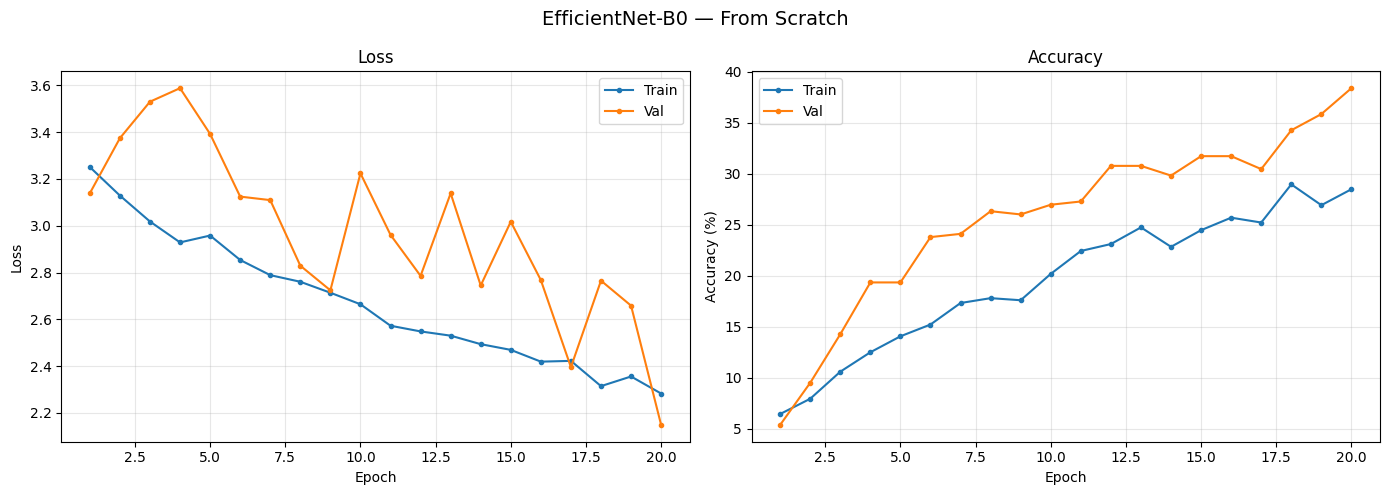

In [5]:
plot_curves(history_scratch, "EfficientNet-B0 — From Scratch")

In [6]:
acc, bal_acc, _, _ = test_model(model_scratch, test_loader)
print(f"Test Accuracy:          {acc:.2%}")
print(f"Test Balanced Accuracy: {bal_acc:.2%}")

Test Accuracy:          31.11%
Test Balanced Accuracy: 31.11%


---
## Task 3: Train with Pretrained Weights (6 Points)

Create an EfficientNet-B0 with **ImageNet pretrained weights**, train for 20 epochs, and report test accuracy + balanced accuracy.

In [7]:
# TODO: Fill in the two blanks — this time use pretrained weights
model_pretrained = timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES)
model_pretrained = model_pretrained.to(device)

train_loader, val_loader, test_loader, train_ds, val_ds, test_ds = create_dataloaders(model_pretrained)
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 1470, Val: 315, Test: 315


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_pretrained.parameters(), lr=LR)

history_pretrained = train_and_evaluate(
    model_pretrained, train_loader, val_loader, train_ds, val_ds,
    criterion, optimizer, epochs=EPOCHS
)

torch.save(model_pretrained.state_dict(), "uc_merced_pretrained.pth")
save_history(history_pretrained, "history_pretrained.csv")

Epoch 1/20:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 1: Train Loss=3.0344, Train Acc=23.3%, Val Loss=1.5733, Val Acc=54.3%


Epoch 2/20:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 2: Train Loss=1.3589, Train Acc=60.5%, Val Loss=0.7592, Val Acc=76.8%


Epoch 3/20:   0%|          | 0/23 [00:00<?, ?it/s]

...

Epoch 18: Train Loss=0.0878, Train Acc=97.7%, Val Loss=0.0553, Val Acc=98.1%


Epoch 19/20:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 19: Train Loss=0.1282, Train Acc=96.3%, Val Loss=0.0605, Val Acc=97.1%


Epoch 20/20:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch 20: Train Loss=0.1125, Train Acc=96.7%, Val Loss=0.0479, Val Acc=98.4%
History saved to history_pretrained.csv


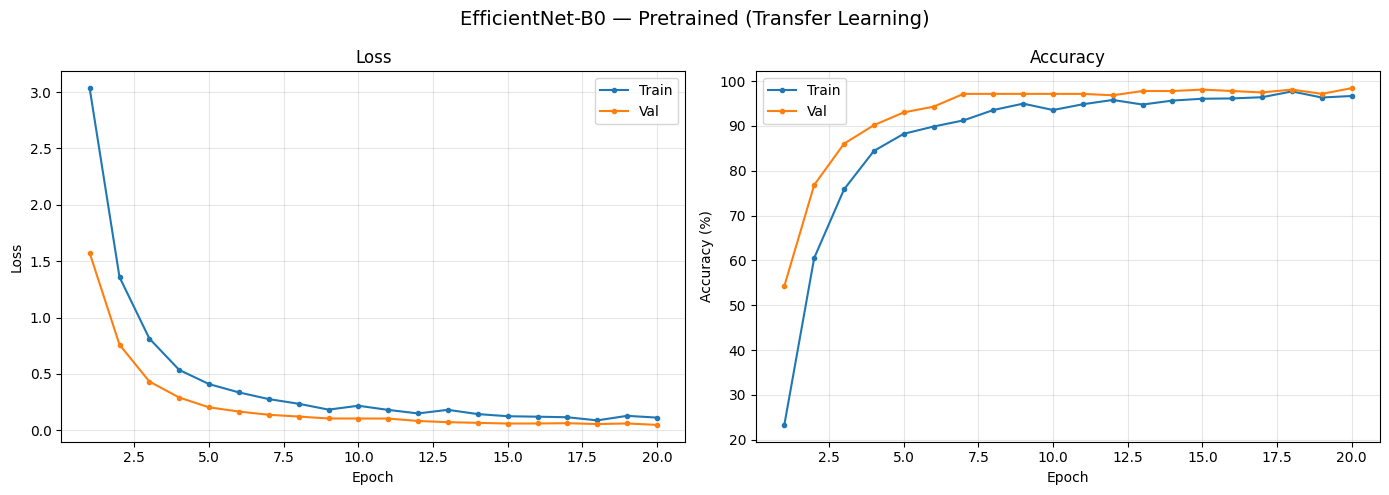

In [9]:
plot_curves(history_pretrained, "EfficientNet-B0 — Pretrained (Transfer Learning)")

In [10]:
acc, bal_acc, _, _ = test_model(model_pretrained, test_loader)
print(f"Test Accuracy:          {acc:.2%}")
print(f"Test Balanced Accuracy: {bal_acc:.2%}")

Test Accuracy:          96.83%
Test Balanced Accuracy: 96.83%
